<a href="https://colab.research.google.com/github/thejclan/CaliforniaHousePricePrediction/blob/main/Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras import regularizers
from sklearn.model_selection import train_test_split
import numpy
from copy import copy
import random
from scipy import stats

tf.random.set_seed(42)
random.seed(42)

#**資料集前處理**

In [ ]:
import numpy as np
import pandas as pd
import sklearn
from sklearn import preprocessing


dataset = pd.read_csv('/content/sample_data/california_housing_train.csv')
#dataset = dataset[dataset["population"] < 25000]

In [ ]:
dataset.info

<bound method DataFrame.info of        longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0        -114.31     34.19                15.0       5612.0          1283.0   
1        -114.47     34.40                19.0       7650.0          1901.0   
2        -114.56     33.69                17.0        720.0           174.0   
3        -114.57     33.64                14.0       1501.0           337.0   
4        -114.57     33.57                20.0       1454.0           326.0   
...          ...       ...                 ...          ...             ...   
16995    -124.26     40.58                52.0       2217.0           394.0   
16996    -124.27     40.69                36.0       2349.0           528.0   
16997    -124.30     41.84                17.0       2677.0           531.0   
16998    -124.30     41.80                19.0       2672.0           552.0   
16999    -124.35     40.54                52.0       1820.0           300.0   

       population  

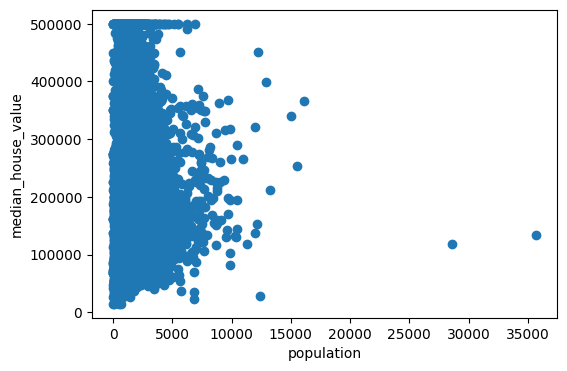

In [ ]:
import matplotlib.pyplot as plt
# Scatter plot
fig, ax = plt.subplots(figsize = (6,4))
ax.scatter(dataset['population'],dataset['median_house_value'])

# x-axis label
ax.set_xlabel('population')

# y-axis label
ax.set_ylabel('median_house_value')
plt.show()

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

s = np.std(dataset.iloc[:,-1]).reshape([-1,1])
X = dataset.iloc[:,:-1].values
Y = dataset.iloc[:,-1].values
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size = 0.2,random_state = 1 )
scaler_x = preprocessing.MinMaxScaler().fit(X_train)
X_train = scaler_x.transform(X_train)

scaler_y = preprocessing.MinMaxScaler().fit(Y_train.reshape(-1,1))
Y_train = scaler_y.transform(Y_train.reshape(-1,1))
X_test = scaler_x.transform(X_test)

print(scaler_y.transform(s)*1.5)

[[0.31232296]]


#**參數設定**

In [ ]:
def get_optimizer(opt_type,lr=0.01):
   if opt_type == 'gradient descent':
     return tf.compat.v1.train.GradientDescentOptimizer(learning_rate=lr)
   if opt_type == 'momentum':
     return tf.compat.v1.train.MomentumOptimizer(learning_rate=lr, momentum=0.9)
   if opt_type == 'adam':
     return tf.compat.v1.train.AdamOptimizer(learning_rate=lr, beta1=0.9, beta2=0.99)

In [ ]:
def Initial_weights(ini_type):

  if ini_type == 'small random number':
    #return 'RandomNormal'
    return tf.keras.initializers.RandomNormal(mean=0.0, stddev=1e-2, seed=42)
  if ini_type == 'Xavier':
    #return 'glorot_normal'
    return tf.keras.initializers.glorot_normal(seed = 42)
  if ini_type == 'Kaiming':
    #return 'he_normal'
    return tf.keras.initializers.he_normal(seed = 42)

In [ ]:
from keras.layers import Activation, Dense

def get_activation(activation_type):
  if activation_type == 'relu':
    return Activation('relu')
  if activation_type == 'tanh':
    return Activation('tanh')

In [ ]:
import math
def decayed_learning_rate(step, decay_steps, initial_learning_rate, alpha =0.0):
  step = min(step, decay_steps)
  cosine_decay = 0.5 * (1 + math.cos(math.pi * step / decay_steps))
  decayed = (1 - alpha) * cosine_decay + alpha
  return initial_learning_rate * decayed

# **WAN MODULE**

In [ ]:
import tensorflow as tf
from tensorflow.keras import regularizers
from sklearn.model_selection import train_test_split
import numpy
from copy import copy
import random
from scipy import stats

tf.random.set_seed(42)
random.seed(42)

In [ ]:
def Weight_tuning_LG_UA(learning_rate = 0.001):

    Acceptable = True

    hyper = {
        "Nomalization" : True,
        "HiddenNode" : 8,
        "Activation" : tf.keras.activations.relu,
        "Initializer" : 'Kaiming',
        "Regularization" : 0.1,
        "Optimizer" : 'gradient descent',
        "Epochs" : 300000,
        "Cosine_Decay" : False,
        "LR_Hasten": 1.2,
        "LR_Slower":0.7,
        "LR_Limit":1e-20
    }

    if (hyper["Nomalization"]):
        X = sklearn.preprocessing.normalize(dataset)[:,:-1]
    else:
        X = dataset.iloc[:,:-1].values
    Y = dataset.iloc[:,-1].values

    # 資料集建立
    X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size = 0.2,random_state = 1 )
    scaler_x = preprocessing.MinMaxScaler().fit(X_train)
    X_train = scaler_x.transform(X_train)

    scaler_y = preprocessing.MinMaxScaler().fit(Y_train.reshape(-1,1))
    Y_train = scaler_y.transform(Y_train.reshape(-1,1))
    X_test = scaler_x.transform(X_test)

    #s = np.std(dataset.iloc[:,-1]).reshape([-1,1])
    #hyper["Gate"] = scaler_y.transform(s)
    hyper["Gate"] = 0.25

    X = tf.convert_to_tensor(X_train)
    y = tf.convert_to_tensor(Y_train)
    y = tf.reshape(y,len(y))

    # 模型建立
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Dense(hyper["HiddenNode"],
                                    input_shape=(X_train.shape[1],),
                                    activation=hyper["Activation"],
                                    kernel_initializer=Initial_weights(hyper["Initializer"]),
                                    activity_regularizer=regularizers.L2(hyper["Regularization"])))
    model.add(tf.keras.layers.Dense(1, activity_regularizer=regularizers.L2(hyper["Regularization"])))

    # 模型訓練
    losses =[]
    baseket = []
    global_step = tf.compat.v1.train.get_or_create_global_step()
    optimizer = get_optimizer(hyper["Optimizer"],learning_rate)

    for t in range(hyper["Epochs"]):
        model_pre = copy(model)
        if(t == 0):
            with tf.GradientTape() as tape:
                y_pred = model(X)
                y_pred = tf.reshape(y_pred,len(y_pred))
                loss_avg= tf.keras.losses.mean_absolute_error(y_pred,y)
            gradients = tape.gradient(loss_avg, model.trainable_variables)
            y_pred = tf.cast(y_pred, "float64")
            max_loss = tf.math.reduce_max(abs(tf.subtract(y_pred, y))).numpy()
        if(hyper["Cosine_Decay"]):
            learning_rate = decayed_learning_rate(t, hyper["Epochs"], learning_rate)

        if(max_loss < hyper["Gate"] and t > 10):
            y_pred = tf.cast(y_pred, "float64")
            max_loss = tf.math.reduce_max(abs(tf.subtract(y_pred, y))).numpy()
            print("-----break------")
            break

        ## UA Module
        UA_Module = True
        Limit = False
        while UA_Module :

            optimizer = get_optimizer(hyper["Optimizer"],learning_rate)
            optimizer.apply_gradients(zip(gradients, model.trainable_variables), global_step=global_step)

            with tf.GradientTape() as tape:
                y_pred = model(X[:])
                y_pred = tf.reshape(y_pred,len(y_pred))
                loss_after_avg = tf.keras.losses.mean_absolute_error(y_pred,y)
            gradients = tape.gradient(loss_after_avg , model.trainable_variables)

            #gradients = tape.gradient(loss_after_avg, model.trainable_variables)

            if(loss_after_avg < loss_avg):
                loss_avg = loss_after_avg
                learning_rate = learning_rate * hyper["LR_Hasten"]
                UA_Module = False
            else:
                if(learning_rate < hyper["LR_Limit"]):
                    Limit = True
                    UA_Module = False
                    Acceptable = False
                else:
                    model = copy(model_pre)
                    learning_rate = learning_rate * hyper["LR_Slower"]

        if(Limit):
            Acceptable = False
            print(learning_rate)
            print("UA_Module limit arrived,  Epoch:", t)
            break

        y_pred = tf.cast(y_pred, "float64")
        max_loss = tf.math.reduce_max(abs(tf.subtract(y_pred, y))).numpy()
        if(max_loss < hyper["Gate"] and t>10):
            print("Acceptable Model!  -------")
            print("loss:", loss_after_avg)
            print("max_loss:", max_loss)
            print("epoch:",t)
            break

        if(t % 50 == 0):
            #print(loss)
            #print(gradients)
            print("pred:", tf.get_static_value(y_pred[tf.math.argmax(abs(tf.subtract(y_pred, y)))]))
            print("real:", tf.get_static_value(y[tf.math.argmax(abs(tf.subtract(y_pred, y)))]))
            print('epoch: %d, loss: %f, max_loss: %f, learning_rate: %f' %(t,loss_after_avg,max_loss,learning_rate))

        if(t % 100 == 0):
                prediction = model.predict(X_test)
                prediction = prediction.reshape(len(Y_test),1)
                prediction = scaler_y.inverse_transform(prediction)
                prediction = prediction.reshape(len(prediction))
                avg_loss = np.average(tf.keras.losses.mean_absolute_error(prediction,Y_test))
                hyper["avg_loss"] = avg_loss
                hyper["min_loss"] = tf.math.reduce_min(abs(tf.subtract(prediction, Y_test))).numpy()
                hyper["max_loss"] = tf.math.reduce_max(abs(tf.subtract(prediction, Y_test))).numpy()
                print("aveg test loss: " ,avg_loss)
                print("minimum test loss: " ,hyper["min_loss"])
                print("maximum test loss: " ,hyper["max_loss"])
                print("norm: " ,hyper["Nomalization"])
                print("----------------------")

    # 模型推論
    prediction = model.predict(X_test)
    prediction = prediction.reshape(len(Y_test),1)
    prediction = scaler_y.inverse_transform(prediction)
    prediction = prediction.reshape(len(prediction))
    avg_loss = np.average(tf.keras.losses.mean_absolute_error(prediction,Y_test))
    hyper["avg_loss"] = avg_loss
    hyper["min_loss"] = tf.math.reduce_min(abs(tf.subtract(prediction, Y_test))).numpy()
    hyper["max_loss"] = tf.math.reduce_max(abs(tf.subtract(prediction, Y_test))).numpy()
    print("aveg test loss: " ,avg_loss)
    print("minimum test loss: " ,hyper["min_loss"])
    print("maximum test loss: " ,hyper["max_loss"])
    print("norm: " ,hyper["Nomalization"])
    print("----------------------")

    if(max_loss > hyper["Gate"]):
        Acceptable = False
        print("-------------- unAcceptable Model (Epoch Limit)  -------")

    return model,Acceptable,hyper["Gate"],max_loss


In [ ]:
def Analogizing_Ri_RE_SO_MU(unAccept_model,gate):

    X = sklearn.preprocessing.normalize(dataset)[:,:-1]
    Y = dataset.iloc[:,-1].values

    # ----- 資料集建立
    X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size = 0.2,random_state = 1 )
    scaler_x = preprocessing.MinMaxScaler().fit(X_train)
    X_train = scaler_x.transform(X_train)
    scaler_y = preprocessing.MinMaxScaler().fit(Y_train.reshape(-1,1))
    Y_train = scaler_y.transform(Y_train.reshape(-1,1))
    X_test = scaler_x.transform(X_test)

    X = tf.convert_to_tensor(X_train)
    y = tf.convert_to_tensor(Y_train)
    y = tf.reshape(y,len(y))


    # ------ 先 Forward 找出，Xk
    y_pred = unAccept_model(X)
    y_pred = tf.reshape(y_pred,len(y_pred))
    y_pred = tf.cast(y_pred, "float64")
    print("目前的 Max Loss : %f ; 而 Loss 應小於 : %f" %(tf.math.reduce_max(abs(tf.subtract(y_pred, y))).numpy(),gate))
    loss = abs(tf.subtract(y_pred, y)).numpy()
    print("因此跑太遠的 X_k 有這些 （一列為一個X_k喔！）: \n",X_train[loss>gate])


    k = tf.convert_to_tensor(X_train[loss>gate]) # 找不要的
    c = tf.convert_to_tensor(X_train[loss<gate]) # 找其餘的
    y_k = tf.convert_to_tensor(Y_train[loss>gate])
    un = len(k) # 從最後一顆開始
    z = 1e-2    # zeta 設為 1e-3
    node_num = unAccept_model.trainable_variables[0].numpy().shape[1]

    while(un >0):
        assign_weight = True
        #------  找適當的 r
        r = tf.convert_to_tensor(np.random.rand(1,X_train.shape[1])*-0.005)
        for i in range(len(c)):
            c_k = tf.convert_to_tensor((c[i] - k[un-1]).numpy().reshape(X_train.shape[1],1))
            r_c_k = tf.matmul(r, c_k)
            if((r_c_k[0] == 0) or ((z+r_c_k) * (z-r_c_k) >= 0)):
                assign_weight = False
                break

        if(assign_weight):

            #------  找到就可以 assign weight, bias 了～
            node_num +=3
            temp_model = tf.keras.Sequential()
            temp_model.add(tf.keras.layers.Dense(node_num,
                                            input_shape=(X_train.shape[1],),
                                            activation=tf.keras.activations.relu,
                                            activity_regularizer=regularizers.L2(0.1)))
            temp_model.add(tf.keras.layers.Dense(1,activity_regularizer=regularizers.L2(0.1)))

            print("\n ----- 加入三顆後的的模型 -----")

            # hidden_node_weight
            hidden_node_1 = unAccept_model.trainable_variables[0]
            node_np = hidden_node_1.numpy()
            for i in range(3):
                node_np = np.append(node_np,r.numpy().reshape([X_train.shape[1],1]),axis=1)
            B = tf.convert_to_tensor(node_np)
            print("hidden_node weight:",B)

            # hidden_node_bias
            hidden_node = unAccept_model.trainable_variables[1]
            node_np = hidden_node.numpy()
            r_k = tf.matmul(r, tf.convert_to_tensor(k[un-1]).numpy().reshape(X_train.shape[1],1))
            bias_1 = z-r_k
            node_np = np.append(node_np,bias_1.numpy()[0],axis=0)
            bias_2 = -r_k
            node_np = np.append(node_np,bias_2.numpy()[0],axis=0)
            bias_3 = -z-r_k
            node_np = np.append(node_np,bias_3.numpy()[0],axis=0)
            C = tf.convert_to_tensor(node_np)
            print("hidden_node bias:",C)

            # output_node_weight
            hidden_node = unAccept_model.trainable_variables[0].numpy()

            x_k = tf.convert_to_tensor(k[un-1]).numpy().reshape(X_train.shape[1],1)
            sum_w_a = 0

            for i in range(node_num -3):
                hidden_bias = tf.cast(unAccept_model.trainable_variables[1][i],dtype="float64")
                a = tf.math.maximum(tf.matmul(tf.convert_to_tensor((np.hsplit(hidden_node,[1])[0].reshape(1,X_train.shape[1])),dtype="float64"),x_k) + hidden_bias,0)
                sum_w_a += a.numpy()*unAccept_model.trainable_variables[2][i].numpy()
                hidden_node = np.delete(hidden_node,0,axis=1)

            y_k = tf.convert_to_tensor(y[loss>gate])
            output_weight_1 = (y_k[un-1].numpy() - unAccept_model.trainable_variables[3].numpy()-sum_w_a)/z
            output_weight_2 = (y_k[un-1].numpy() - unAccept_model.trainable_variables[3].numpy()-sum_w_a)/z
            output_weight_3 = -2 * (y_k[un-1].numpy() - unAccept_model.trainable_variables[3].numpy()-sum_w_a)/z

            hidden_node = unAccept_model.trainable_variables[2]
            node_np = hidden_node.numpy()
            node_np = np.append(node_np,output_weight_1 ,axis=0)
            node_np = np.append(node_np,output_weight_2 ,axis=0)
            node_np = np.append(node_np,output_weight_3 ,axis=0)
            D = tf.convert_to_tensor(node_np)
            print("output_node weight:", D)

            # assign
            temp_model.layers[0].set_weights([B,C])
            temp_model.layers[1].set_weights([D,unAccept_model.trainable_variables[3]])
            unAccept_model = copy(temp_model)
            un -= 1
            y_pred = unAccept_model(X)
            y_pred = tf.reshape(y_pred,len(y_pred))
            y_pred = tf.cast(y_pred, "float64")
            print("\n目前的 Max Loss : %f ;  而 Learning-Goal 為： %f" %(tf.math.reduce_max(abs(tf.subtract(y_pred, y))).numpy(),gate))



    return unAccept_model

In [ ]:
def Network_Tuning_4(Accept_model,gate):
    import random
    X = sklearn.preprocessing.normalize(dataset)[:,:-1]
    Y = dataset.iloc[:,-1].values

    # 資料集建立
    X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size = 0.2,random_state = 1 )
    scaler_x = preprocessing.MinMaxScaler().fit(X_train)
    X_train = scaler_x.transform(X_train)
    scaler_y = preprocessing.MinMaxScaler().fit(Y_train.reshape(-1,1))
    Y_train = scaler_y.transform(Y_train.reshape(-1,1))
    X_test = scaler_x.transform(X_test)

    X = tf.convert_to_tensor(X_train)
    y = tf.convert_to_tensor(Y_train)
    y = tf.reshape(y,len(y))

    done = False
    global_step = tf.compat.v1.train.get_or_create_global_step()
    optimizer = get_optimizer('gradient descent',0.001)
    setattr(Accept_model.layers[-2], "activity_regularizer", tf.keras.regularizers.l2(0.001))
    setattr(Accept_model.layers[-1], "activity_regularizer", tf.keras.regularizers.l2(0.001))
    delete_node = 0

    for i in range(Accept_model.trainable_variables[2].shape[0]):

        delete_node = np.argmin(np.absolute(Accept_model.trainable_variables[2].numpy()))
        print("現在 output layer 最小的node : %d" %(delete_node+1))

        # Model built
        model = tf.keras.Sequential()
        model.add(tf.keras.layers.Dense(Accept_model.trainable_variables[0].numpy().shape[1]-1,
                                        input_shape=(X_train.shape[1],),
                                        activation=tf.keras.activations.relu,
                                        activity_regularizer=regularizers.L2(0.001))) # regulizing

        model.add(tf.keras.layers.Dense(1, activity_regularizer=regularizers.L2(0.001)))

        hidden_node = Accept_model.trainable_variables[0]
        node_np = hidden_node.numpy()
        node_np = np.delete(node_np,delete_node,axis=1)
        B = tf.convert_to_tensor(node_np)

        hidden_node = Accept_model.trainable_variables[1]
        node_np = hidden_node.numpy()
        node_np = np.delete(node_np,delete_node,axis=0)
        C = tf.convert_to_tensor(node_np)

        hidden_node = Accept_model.trainable_variables[2]
        node_np = hidden_node.numpy()
        node_np = np.delete(node_np,delete_node,axis=0)
        D = tf.convert_to_tensor(node_np)

        model.layers[0].set_weights([B,C])
        model.layers[1].set_weights([D,Accept_model.trainable_variables[3]])

        # Predict for w'
        weight_tuning = True
        lr = 0.001
        run = 0
        fail = 0

        while(weight_tuning):
            done = False
            pre_model = copy(model) # store the weight
            if(run == 0):
                with tf.GradientTape() as tape:
                    y_pred = model(X)
                    y_pred = tf.reshape(y_pred,len(y_pred))
                    pre_loss= tf.keras.losses.mean_absolute_error(y_pred,y) + tf.cast(tf.add_n(model.losses), dtype="float64")
                gradients = tape.gradient(pre_loss, model.trainable_variables)
                y_pred = tf.cast(y_pred, "float64")
                max_loss = tf.math.reduce_max(abs(tf.subtract(y_pred, y))).numpy()
                optimizer = get_optimizer('gradient descent',lr)
                optimizer.apply_gradients(zip(gradients, model.trainable_variables), global_step=global_step) # born the weight'
            print(max_loss)

            # Acceptable or Unacceptable
            if(max_loss<gate):
                weight_tuning = False
            else:
                # Is getting better or worst
                while(not(done)):
                    if(lr < 1e-8):
                        weight_tuning = False
                        done = True
                    with tf.GradientTape() as tape:
                        y_pred = model(X)
                        y_pred = tf.reshape(y_pred,len(y_pred))
                        loss_avg= tf.keras.losses.mean_absolute_error(y_pred,y) + tf.cast(tf.add_n(model.losses), dtype="float64")
                    gradients = tape.gradient(loss_avg, model.trainable_variables)
                    y_pred = tf.cast(y_pred, "float64")
                    optimizer = get_optimizer('gradient descent',lr)
                    optimizer.apply_gradients(zip(gradients, model.trainable_variables), global_step=global_step)

                    if(loss_avg < pre_loss): # getting better case
                        lr *= 1.2
                        pre_loss = loss_avg
                        done = True
                    else:   # getting wost case
                        lr *= 0.8
                        model = copy(pre_model)

        # Acceptable or not
        if(max_loss<gate):

            fail = 0
            Accept_model = copy(model)

            # Regularizing L2 EB module for w'
            # The regulirization is been set in keras model using tf.keras.regularizers.l2(0.001) ahead

            for epoch in range(500):
                with tf.GradientTape() as tape:
                    y_pred = Accept_model(X)
                    y_pred = tf.reshape(y_pred,len(y_pred))
                    loss_avg= tf.keras.losses.mean_absolute_error(y_pred,y) + tf.cast(tf.add_n(Accept_model.losses), dtype="float64")
                gradients = tape.gradient(loss_avg, Accept_model.trainable_variables)
                optimizer.apply_gradients(zip(gradients, Accept_model.trainable_variables), global_step=global_step)

            print("刪除第 %d 顆 node" %(delete_node+1))

        else:
            y_pred = Accept_model(X)
            y_pred = tf.reshape(y_pred,len(y_pred))
            y_pred = tf.cast(y_pred, "float64")
            max_loss = tf.math.reduce_max(abs(tf.subtract(y_pred, y))).numpy()
            print('因 Unacceptable 停止訓練，並回復成前次模型')
            print('回復後的 max-loss：', max_loss)
            break

        print("--------------------------")
    return Accept_model

# **MAIN**

In [ ]:
#@title
# ----------- Main ----------------

model_wt, Acceptable, gate,max_loss = Weight_tuning_LG_UA()

if(Acceptable):
    print("\n------ 進入Network_Tuning_4 ---------\n")
    model_final = Network_Tuning_4(model_wt,gate[0])
else:
    print("\n------ 進入 Analogizing_Ri_RE_SO_MU ---------\n")
    model_analogizing = Analogizing_Ri_RE_SO_MU(model_wt,gate[0])
    print("ps. 這邊會發現成功將 TOP1 MAXLOSS 去除了，現在的MAX LOSS 是 TOP2 的 MAXLOSS ！")
    print("\n------ 進入 Network_Tuning_4 ---------\n")
    model_final = Network_Tuning_4(model_analogizing,gate[0])
    print("\n------ Model 完成 ---------\n")

串流輸出內容已截斷至最後 5000 行。
minimum test loss:  5.171875
maximum test loss:  180623.77
norm:  True
----------------------
pred: -0.28164422512054443
real: 0.0
epoch: 121450, loss: 0.016742, max_loss: 0.281644, learning_rate: 0.003039
pred: -0.2816091775894165
real: 0.0
epoch: 121500, loss: 0.016740, max_loss: 0.281609, learning_rate: 0.005299
107/107 [==============================] - 0s 1ms/step
aveg test loss:  8226.979764691521
minimum test loss:  4.875
maximum test loss:  180649.39
norm:  True
----------------------
pred: -0.2815437316894531
real: 0.0
epoch: 121550, loss: 0.016738, max_loss: 0.281544, learning_rate: 0.009238
pred: -0.28153061866760254
real: 0.0
epoch: 121600, loss: 0.016736, max_loss: 0.281531, learning_rate: 0.001895
107/107 [==============================] - 0s 1ms/step
aveg test loss:  8225.199250847312
minimum test loss:  2.296875
maximum test loss:  180677.34
norm:  True
----------------------
pred: -0.281489759683609
real: 0.0
epoch: 121650, loss: 0.016735, max_loss

TypeError: ignored

In [ ]:
model_wt = tf.keras.saving.load_model('/content/drive/MyDrive/Alogrithm Class/final/model_wt')

In [ ]:
model_analogizing = Analogizing_Ri_RE_SO_MU(model_wt,0.24)

目前的 Max Loss : 0.249997 ; 而 Loss 應小於 : 0.240000
因此跑太遠的 X_k 有這些 （一列為一個X_k喔！）: 
 [[0.         1.         0.69372041 0.01675905 0.02734856 0.00447016
  0.00936301 0.12373701]
 [0.00374579 0.98459378 0.30763077 0.04366113 0.07148011 0.02122561
  0.04500224 0.39394392]]


In [ ]:
gate = 0.25
model_final = Network_Tuning_4(model_wt,gate)

現在 output layer 最小的node : 5
0.2393174763480429
刪除第 5 顆 node
--------------------------
現在 output layer 最小的node : 3
0.23791640956795257
刪除第 3 顆 node
--------------------------
現在 output layer 最小的node : 2
0.5222198963165283
0.5222199559211731
0.5222210884094238
0.5222222805023193
0.5222236514091492
0.522226095199585
0.5222298502922058
0.5222344398498535
0.5222361087799072
0.5222429037094116
0.522253155708313
0.5222647190093994
0.5222666263580322
因 Unacceptable 停止訓練，並回復成前次模型
回復後的 max-loss： 0.24128624756729644


# **最終模型預測效果 （測試集中的100筆資料）：**

In [ ]:
# 資料集建立
dataset = pd.read_csv('/content/sample_data/california_housing_test.csv')
X = sklearn.preprocessing.normalize(dataset)[:,:-1]
Y = dataset.iloc[:,-1].values
X_test = scaler_x.transform(X)


X = tf.convert_to_tensor(X_test)

y_pred = model_final(X)

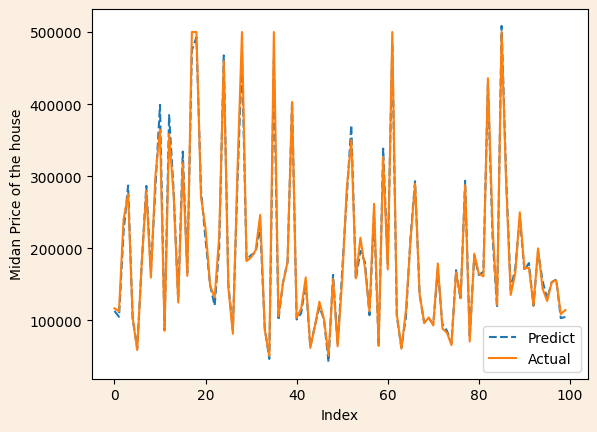

In [ ]:
# importing package
import matplotlib.pyplot as plt
plt.figure(facecolor='#faefe0')
plt.ylabel("Midan Price of the house") # y label
plt.xlabel("Index") # x label
plt.plot(scaler_y.inverse_transform(y_pred[100:200]), linestyle = 'dashed',label = "Predict")
plt.plot(Y[100:200], label = "Actual")

plt.legend()
plt.show()

In [ ]:
stand = np.std(Y) *1.5
goal = np.array(stand < abs(scaler_y.inverse_transform(y_pred).reshape(-1) - Y))
print("誤差在 1.5倍標準差內 的機率：",goal[0].sum()/len(Y))
print("MAE: ",tf.keras.losses.MeanAbsoluteError()(scaler_y.inverse_transform(y_pred).reshape(-1),Y).numpy())

誤差在 1.5倍標準差內 的機率： 0.0
MAE:  7232.261323921184


# **BASELINE**

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
dataset = pd.read_csv('/content/sample_data/california_housing_train.csv')
s = np.std(dataset.iloc[:,-1]).reshape([-1,1])
X = sklearn.preprocessing.normalize(dataset)[:,:-1]
Y = dataset.iloc[:,-1].values
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size = 0.2,random_state = 1 )
scaler_x = preprocessing.MinMaxScaler().fit(X_train)
X_train = scaler_x.transform(X_train)

scaler_y = preprocessing.MinMaxScaler().fit(Y_train.reshape(-1,1))
Y_train = scaler_y.transform(Y_train.reshape(-1,1))
X_test = scaler_x.transform(X_test)

## **Multiple Regression**

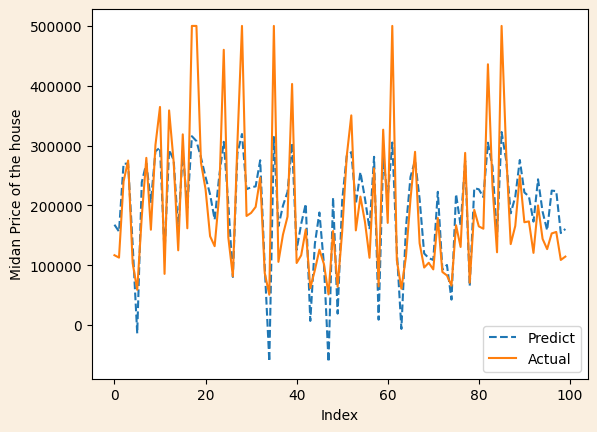

MAE:  50875.082427933245


In [ ]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train,Y_train)

# 資料集建立
dataset = pd.read_csv('/content/sample_data/california_housing_test.csv')
X = sklearn.preprocessing.normalize(dataset)[:,:-1]
Y = dataset.iloc[:,-1].values
X_test = scaler_x.transform(X)
y_pred = regressor.predict(X_test)

# importing package
import matplotlib.pyplot as plt
plt.figure(facecolor='#faefe0')
plt.ylabel("Midan Price of the house") # y label
plt.xlabel("Index") # x label
plt.plot(scaler_y.inverse_transform(y_pred[100:200]), linestyle = 'dashed',label = "Predict")
plt.plot(Y[100:200], label = "Actual")
plt.legend()
plt.show()

print("MAE: ",tf.keras.losses.MeanAbsoluteError()(scaler_y.inverse_transform(y_pred).reshape(-1),Y).numpy())

## **SVM (Kernal:RBF)**

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


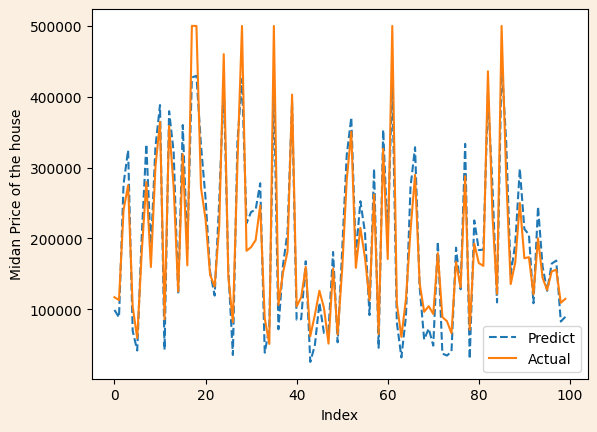

MAE:  32059.280181029917


In [ ]:
from sklearn.svm import SVR
regressor = SVR(kernel = 'rbf')
regressor.fit(X_train, Y_train)

# 資料集建立
dataset = pd.read_csv('/content/sample_data/california_housing_test.csv')
X = sklearn.preprocessing.normalize(dataset)[:,:-1]
Y = dataset.iloc[:,-1].values
X_test = scaler_x.transform(X)
y_pred = regressor.predict(X_test)

# importing package
import matplotlib.pyplot as plt
plt.figure(facecolor='#faefe0')
plt.ylabel("Midan Price of the house") # y label
plt.xlabel("Index") # x label
plt.plot(scaler_y.inverse_transform(y_pred[100:200].reshape(-1,1)), linestyle = 'dashed',label = "Predict")
plt.plot(Y[100:200], label = "Actual")
plt.legend()
plt.show()

print("MAE: ",tf.keras.losses.MeanAbsoluteError()(scaler_y.inverse_transform(y_pred.reshape(-1,1)).reshape(-1),Y).numpy())

## **Decision Tree**

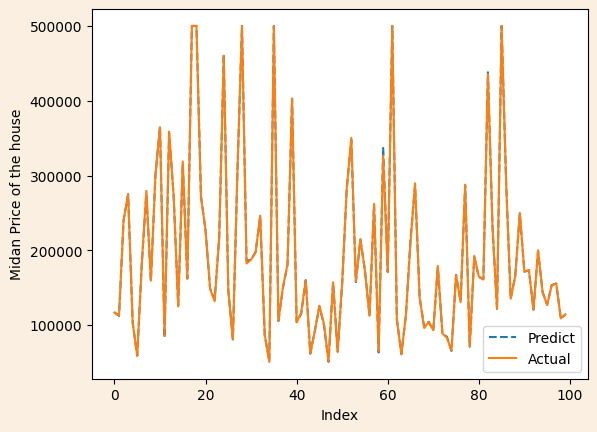

MAE:  890.5046666666672


In [ ]:
from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor(random_state = 42)
regressor.fit(X_train, Y_train)

# 資料集建立
dataset = pd.read_csv('/content/sample_data/california_housing_test.csv')
X = sklearn.preprocessing.normalize(dataset)[:,:-1]
Y = dataset.iloc[:,-1].values
X_test = scaler_x.transform(X)
y_pred = regressor.predict(X_test)

# importing package
import matplotlib.pyplot as plt
plt.figure(facecolor='#faefe0')
plt.ylabel("Midan Price of the house") # y label
plt.xlabel("Index") # x label
plt.plot(scaler_y.inverse_transform(y_pred[100:200].reshape(-1,1)), linestyle = 'dashed',label = "Predict")
plt.plot(Y[100:200], label = "Actual")
plt.legend()
plt.show()

print("MAE: ",tf.keras.losses.MeanAbsoluteError()(scaler_y.inverse_transform(y_pred.reshape(-1,1)).reshape(-1),Y).numpy())

<ipython-input-32-1cd986417824>:3: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  regressor.fit(X_train, Y_train)


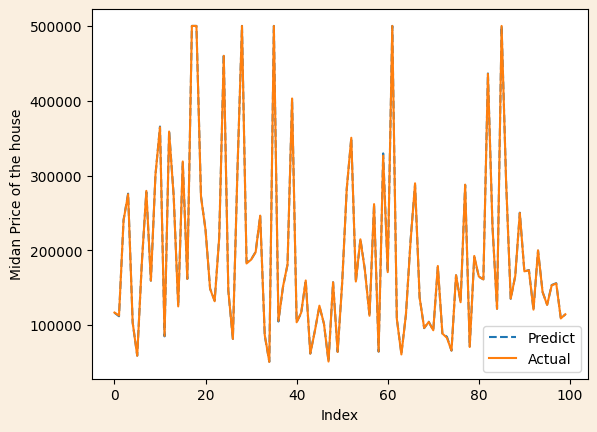

MAE:  710.054666666667


In [ ]:
from sklearn.ensemble import RandomForestRegressor
regressor = RandomForestRegressor(n_estimators = 10, random_state=42)
regressor.fit(X_train, Y_train)

# 資料集建立
dataset = pd.read_csv('/content/sample_data/california_housing_test.csv')
X = sklearn.preprocessing.normalize(dataset)[:,:-1]
Y = dataset.iloc[:,-1].values
X_test = scaler_x.transform(X)
y_pred = regressor.predict(X_test)

# importing package
import matplotlib.pyplot as plt
plt.figure(facecolor='#faefe0')
plt.ylabel("Midan Price of the house") # y label
plt.xlabel("Index") # x label
plt.plot(scaler_y.inverse_transform(y_pred[100:200].reshape(-1,1)), linestyle = 'dashed',label = "Predict")
plt.plot(Y[100:200], label = "Actual")
plt.legend()
plt.show()

print("MAE: ",tf.keras.losses.MeanAbsoluteError()(scaler_y.inverse_transform(y_pred.reshape(-1,1)).reshape(-1),Y).numpy())

# **測試 Analogizing**

In [ ]:
# This mounts your Google Drive to the Colab VM.
from google.colab import drive
drive.mount('/content/drive')

# TODO: Enter the foldername in your Drive where you have saved the unzipped
FOLDERNAME = 'CNN/archive'
assert FOLDERNAME is not None, "[!] Enter the foldername."

# Now that we've mounted your Drive, this ensures that
# the Python interpreter of the Colab VM can load
# python files from within it.
import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

Mounted at /content/drive


In [ ]:
model_wt.save('/content/drive/MyDrive/Alogrithm Class/final/model_wt')

In [ ]:
temp_model.trainable_variables[0]

<tf.Variable 'dense_14/kernel:0' shape=(8, 14) dtype=float32, numpy=
array([[ 0.7300618 , -0.8831417 , -0.02390618,  0.82479584, -0.07713111,
         0.71442604,  0.8238729 , -0.26759657,  0.17619772,  0.17619772,
         0.17619772,  0.9202852 ,  0.9202852 ,  0.9202852 ],
       [-0.9150913 ,  0.6182189 , -0.25017926, -0.09875247,  0.61633205,
        -1.7659446 , -1.6253033 ,  0.08779288,  0.7598443 ,  0.7598443 ,
         0.7598443 ,  0.12208673,  0.12208673,  0.12208673],
       [-0.00771209,  0.15837033,  0.75534755,  0.6291474 ,  0.46168232,
        -0.8094156 , -0.67012334,  0.4438213 ,  0.7408335 ,  0.7408335 ,
         0.7408335 ,  0.45247653,  0.45247653,  0.45247653],
       [ 0.8463676 ,  0.4333246 , -0.649493  , -0.81152624,  0.5819602 ,
        -0.3714841 , -0.2831867 ,  0.2125587 ,  0.04760121,  0.04760121,
         0.04760121,  0.36437476,  0.36437476,  0.36437476],
       [-0.56473327,  0.33846372, -0.73199534, -0.03209344, -0.4648602 ,
        -0.2901005 , -0.703064

In [ ]:
# hidden_node_weight
hidden_node = unAccept_model.trainable_variables[0]
node_np = hidden_node.numpy()
for i in range(3):
    node_np = np.append(node_np,r.numpy().reshape([8,1]),axis=1)
B = tf.convert_to_tensor(node_np)

# hidden_node_bias
hidden_node = unAccept_model.trainable_variables[1]
node_np = hidden_node.numpy()
r_k = tf.matmul(r, tf.convert_to_tensor(k[un-1]).numpy().reshape(X_train.shape[1],1))
bias_1 = zeta - r_k
node_np = np.append(node_np,bias_1.numpy()[0],axis=0)
bias_2 = -r_k
node_np = np.append(node_np,bias_2.numpy()[0],axis=0)
bias_3 = -zeta - r_k
node_np = np.append(node_np,bias_3.numpy()[0],axis=0)
C = tf.convert_to_tensor(node_np)

# output_node_weight
hidden_node = unAccept_model.trainable_variables[0].numpy()

x_k = tf.convert_to_tensor(k[un-1]).numpy().reshape(X_train.shape[1],1)
sum_w_a = 0

for i in range(len(C) -3):
    a = tf.matmul(tf.convert_to_tensor((np.hsplit(hidden_node,[1])[0].reshape(1,X_train.shape[1])),dtype="float64"), x_k)
    sum_w_a += a.numpy()*unAccept_model.trainable_variables[2][0].numpy()
    hidden_node = np.delete(hidden_node,0,axis=1)

y_k = tf.convert_to_tensor(y[loss>gate])
output_weight_1 = (y_k[un-1].numpy() - unAccept_model.trainable_variables[3].numpy()-sum_w_a)/zeta
output_weight_2 = (y_k[un-1].numpy() - unAccept_model.trainable_variables[3].numpy()-sum_w_a)/zeta
output_weight_3 = -2 * (y_k[un-1].numpy() - unAccept_model.trainable_variables[3].numpy()-sum_w_a)/zeta

hidden_node = unAccept_model.trainable_variables[2]
node_np = hidden_node.numpy()
node_np = np.append(node_np,output_weight_1 ,axis=0)
node_np = np.append(node_np,output_weight_2 ,axis=0)
node_np = np.append(node_np,output_weight_3 ,axis=0)
D = tf.convert_to_tensor(node_np)



NameError: ignored

In [ ]:
unAccept_model.trainable_variables[2][0]

<tf.Tensor: shape=(1,), dtype=float32, numpy=array([1.5172651], dtype=float32)>

In [ ]:
unAccept_model.trainable_variables[3]

array([-0.14150009], dtype=float32)

In [ ]:
y_k = tf.convert_to_tensor(y[loss>gate])
y_k[un-1].numpy() - unAccept_model.trainable_variables[3].numpy()

array([0.14150009], dtype=float32)

In [ ]:
s = np.std(dataset.iloc[:,-1]).reshape([-1,1])
gate = scaler_y.transform(s)*1.5
model_analogizing = Analogizing_Ri_RE_SO_MU(model_wt,gate[0])

目前的 Max Loss : 0.32929128408432007
[[0.         1.         0.6937205  0.01313139 0.02141378 0.00344044
  0.00667126 0.1250149 ]]
B: tf.Tensor(
[[ 7.97684371e-01 -8.76541376e-01 -2.74514314e-02  8.70311737e-01
  -8.98727775e-02  8.01677883e-01  9.13632810e-01 -2.97836244e-01
  -8.56159337e-02 -8.56159337e-02 -8.56159337e-02]
 [-9.13205385e-01  6.28087282e-01 -2.53153205e-01 -6.65856525e-02
   6.06274784e-01 -1.87815619e+00 -1.77049148e+00  5.64472489e-02
  -2.86226443e-02 -2.86226443e-02 -2.86226443e-02]
 [ 4.58944626e-02  1.65716335e-01  7.52254844e-01  6.14665031e-01
   4.66570079e-01 -6.79860830e-01 -6.49704099e-01  4.58671123e-01
  -2.52616301e-02 -2.52616301e-02 -2.52616301e-02]
 [ 8.74526501e-01  4.33724493e-01 -6.49408340e-01 -7.66494393e-01
   5.67204356e-01 -3.18987668e-01 -2.55303085e-01  1.70577496e-01
  -7.44965543e-02 -7.44965543e-02 -7.44965543e-02]
 [-5.91758847e-01  3.39991629e-01 -7.32143402e-01 -1.14900684e-02
  -4.69910175e-01 -2.47955814e-01 -6.90557420e-01 -3.186400

In [ ]:
model_final = Network_Tuning_4(model_analogizing,gate[0])

gate: [[0.31231218]]
現在 output layer 最小的node : 5
0.20995213516881273
刪除第 5 顆 node
--------------------------
現在 output layer 最小的node : 3
0.2375076604716997
刪除第 3 顆 node
--------------------------
現在 output layer 最小的node : 2
0.4577343463897705
0.45773547887802124
0.4577375650405884
0.4577397108078003
0.45774221420288086
0.4577452540397644
0.4577481746673584
0.45775169134140015
0.45776018500328064
0.45777028799057007
0.45777785778045654
0.4577906131744385
0.4578104019165039
0.45784497261047363
0.45795828104019165
回復後的 max-loss： 0.23627354630162523
因 Unacceptable 停止訓練


In [ ]:
model_final = Network_Tuning_4(model_analogizing)
model_final.trainable_variables

現在 output layer 最小的node : 5
13.967153732334443
回復後的 max-loss： 13.967153732334443
因 Unacceptable 停止訓練


[<tf.Variable 'dense_2/kernel:0' shape=(8, 11) dtype=float32, numpy=
 array([[ 0.7976844 , -0.8765414 , -0.02745143,  0.87031174, -0.08987278,
          0.8016779 ,  0.9136328 , -0.29783624,  0.17694469,  0.17694469,
          0.17694469],
        [-0.9132054 ,  0.6280873 , -0.2531532 , -0.06658565,  0.6062748 ,
         -1.8781562 , -1.7704915 ,  0.05644725,  0.4239265 ,  0.4239265 ,
          0.4239265 ],
        [ 0.04589446,  0.16571634,  0.75225484,  0.61466503,  0.46657008,
         -0.67986083, -0.6497041 ,  0.45867112,  0.77988297,  0.77988297,
          0.77988297],
        [ 0.8745265 ,  0.4337245 , -0.64940834, -0.7664944 ,  0.56720436,
         -0.31898767, -0.25530308,  0.1705775 ,  0.7583859 ,  0.7583859 ,
          0.7583859 ],
        [-0.59175885,  0.33999163, -0.7321434 , -0.01149007, -0.46991017,
         -0.24795581, -0.6905574 , -0.31864008,  0.82700163,  0.82700163,
          0.82700163],
        [-0.80291754,  0.52867514,  0.7018841 ,  0.08651439, -0.3058257 ,
  